In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import os
import random

B = low
mono = high


In [ ]:
low_data = np.load('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/Real_Low_genomap.npy')
low_data.shape

(1415, 40, 40, 1)

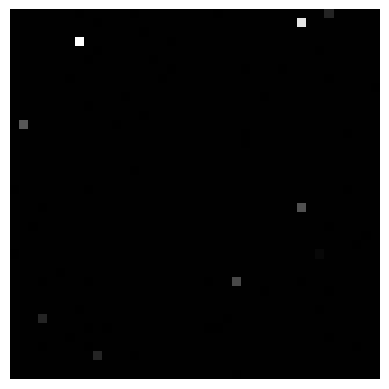

In [ ]:
image = low_data[1]
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
high_data = np.load('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/Real_High_genomap.npy')
high_data.shape

(1415, 40, 40, 1)

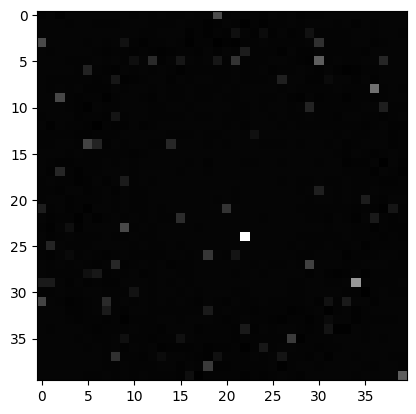

In [ ]:
image = high_data[1]
plt.imshow(image, cmap='gray')
plt.show()

In [ ]:
y = [0] * low_data.shape[0] +  [1] * high_data.shape[0]

In [ ]:
data = np.vstack([low_data, high_data ])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=0.20, random_state=42)

In [ ]:
trian_ds = tf.data.Dataset.from_tensor_slices((X_train , y_train ))
trian_ds = trian_ds.shuffle(buffer_size=1000)
trian_ds = trian_ds.batch(32)

In [ ]:
test_ds = tf.data.Dataset.from_tensor_slices((X_test , y_test ))
test_ds = test_ds.batch(32)

In [ ]:
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(40, 40, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), padding='same' ,activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
model = create_model()
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 40, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 453,633 (1.73 MB)

 Trainable params: 453,633 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5 ,  restore_best_weights=True)

In [ ]:
history = model.fit(trian_ds,
                    epochs=1000,
                    validation_data=test_ds,
                    callbacks=[early_stopping])

Epoch 1/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.6267 - loss: 0.6511 - val_accuracy: 0.9329 - val_loss: 0.2957
Epoch 2/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9458 - loss: 0.2202 - val_accuracy: 0.9682 - val_loss: 0.0931
Epoch 3/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9771 - loss: 0.0827 - val_accuracy: 0.9753 - val_loss: 0.0639
Epoch 4/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9902 - loss: 0.0378 - val_accuracy: 0.9841 - val_loss: 0.0413
Epoch 5/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9945 - loss: 0.0182 - val_accuracy: 0.9753 - val_loss: 0.0957
Epoch 6/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9959 - loss: 0.0224 - val_accuracy: 0.9894 - val_loss: 0.0293
Epoch 7/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9999 - loss: 0.0049 - val_accuracy: 0.9876 - val_loss: 0.0407
Epoch 8/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9972 - loss: 0.0108 - val_accuracy: 

In [ ]:
model.save('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/classifier_del_later.h5')

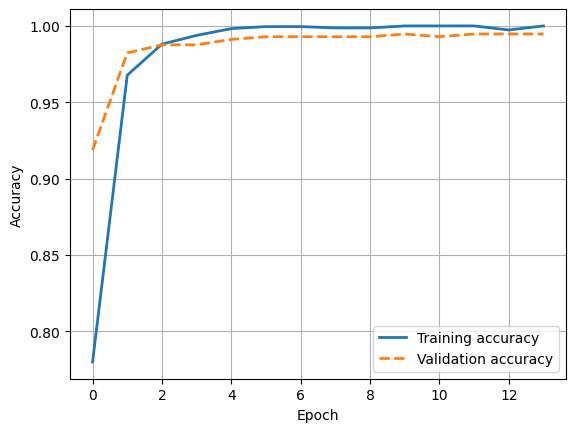

In [ ]:
plt.plot(history.history['accuracy'], linewidth=2)
plt.plot(history.history['val_accuracy'], linewidth=2, linestyle='dashed')
#plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

# Extract values from history.history
epochs = list(range(1, len(history.history['accuracy']) + 1))  # Epoch numbers
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

# Create a DataFrame
df = pd.DataFrame({
    'Epoch': epochs,
    'Training Accuracy': training_accuracy,
    'Validation Accuracy': validation_accuracy
})

# Save to CSV file
df.to_csv('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/training_accuracy_Cancer.csv', index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


CNN Loss Plot

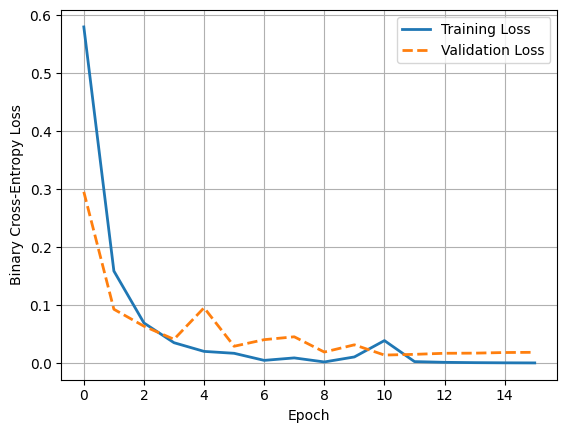

In [ ]:
# Plot CNN Training and Validation Loss
#plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

# Labels and title
#plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)

# Show plot
plt.show()

In [ ]:
import pandas as pd

# Extract values from history.history
epochs = list(range(1, len(history.history['loss']) + 1))  # Epoch numbers
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Create a DataFrame
df = pd.DataFrame({
    'Epoch': epochs,
    'Training Loss': training_loss,
    'Validation Loss': validation_loss
})

# Save to CSV file
df.to_csv('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/training_loss_Cancer.csv', index=False)

print("CSV file saved successfully!")


CSV file saved successfully!


Confusion matrix plot for real image classification

89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Confusion Matrix:
[[1413    2]
 [   2 1413]]
Accuracy: 0.9986
Precision: 0.9986
Recall: 0.9986
F1 Score: 0.9986


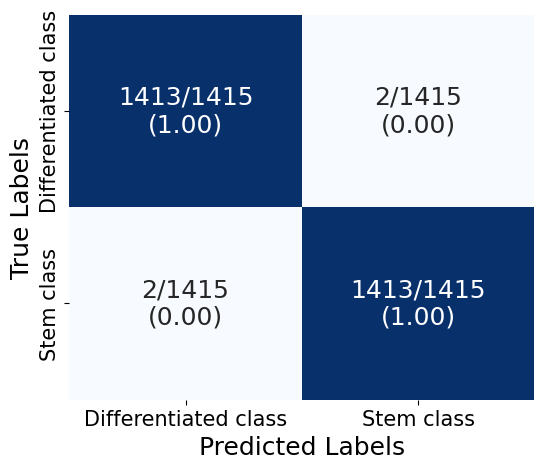

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score

# Load the trained classifier
classifier = tf.keras.models.load_model('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/classifier_del_later.h5')

# Make predictions
predictions = classifier.predict(data)
predicted_labels = (predictions > 0.5).astype(int)

# Compute confusion matrix and metrics
cm = confusion_matrix(y, predicted_labels)
accuracy = accuracy_score(y, predicted_labels)
precision = precision_score(y, predicted_labels)
recall = recall_score(y, predicted_labels)
f1 = f1_score(y, predicted_labels)

# Print results
print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Normalize the confusion matrix (row-wise)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Format labels with count and percentage
labels = np.array([[f"{cm[i, j]}/{cm.sum(axis=1)[i]}\n({cm_normalized[i, j]:.2f})" for j in range(cm.shape[1])] for i in range(cm.shape[0])])

# Define font sizes
label_fontsize = 18  # Font size for labels
tick_fontsize = 15   # Font size for tick labels
annot_fontsize = 18  # Font size for heatmap annotations

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Blues", cbar=False,
            xticklabels=['Differentiated class', 'Stem class'],
            yticklabels=['Differentiated class', 'Stem class'],
            annot_kws={"size": annot_fontsize})  # Custom annotation size

# Set labels and ticks
plt.xlabel("Predicted Labels", fontsize=label_fontsize)
plt.ylabel("True Labels", fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

# Display the plot
plt.show()


Generating images

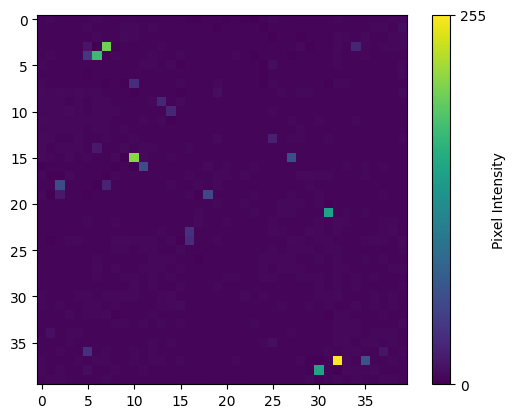

In [ ]:

 #image = high_synthetic_data[11]
 image = low_synthetic_data[15]
#image = low_data[100]
#image = high_data[1]
fake_images = (image - np.min(image))/(np.max(image) - np.min(image))

fake_images *= 255.0

converted_images = fake_images.astype(np.uint8)


img = plt.imshow(converted_images, cmap='viridis',vmin=0, vmax=255)
cbar = plt.colorbar(img)
cbar.set_label('Pixel Intensity')
cbar.set_ticks([0, 255])  # Set the ticks at the min and max values
cbar.set_ticklabels(['0', '255'])

#plt.imsave('/content/drive/MyDrive/GenoMap/image.png', converted_images, cmap='viridis')
plt.show()

Synthetic images evaluation

#b = low; mono = high


In [ ]:
low_synthetic_data = np.load('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/synthetic_Low_2570.npy')
high_synthetic_data = np.load('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/synthetic_High_2570.npy')
classifier = tf.keras.models.load_model('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/classifier_del_later.h5')

In [ ]:
data = np.vstack([low_data, high_data ])
data = data.astype(np.float32)
#data = np.clip(data , -5 ,5)

_MIN = data.min()
_MAX = data.max()

data = -1 + 2*(data - _MIN)/(_MAX - _MIN)

print(_MAX)
print(_MIN)

37.5899
-0.73866487


89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Confusion Matrix:
[[1267  148]
 [   0 1415]]
Accuracy: 0.9477
Precision: 0.9053
Recall: 1.0000
F1 Score: 0.9503


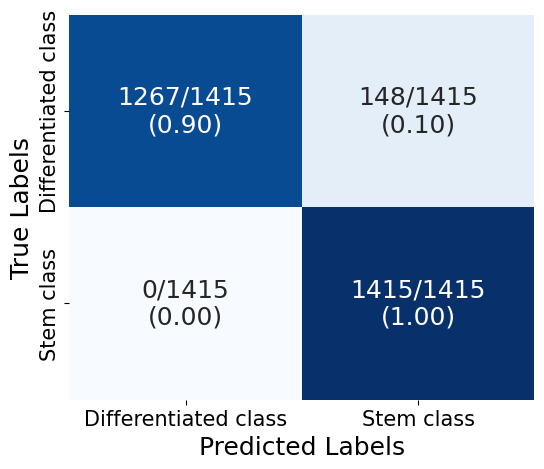

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score

# Stack synthetic data and create labels
synthetic_data = np.vstack([low_synthetic_data, high_synthetic_data])
y = [0] * low_synthetic_data.shape[0] + [1] * high_synthetic_data.shape[0]

# Reverse normalization from tanh
synthetic_data = ((synthetic_data + 1) * (_MAX - _MIN) / 2) + _MIN

# Make predictions
predictions = classifier.predict(synthetic_data)
predicted_labels = (predictions > 0.5).astype(np.float32)

# Compute confusion matrix and metrics
cm = confusion_matrix(y, predicted_labels)
accuracy = accuracy_score(y, predicted_labels)
precision = precision_score(y, predicted_labels)
recall = recall_score(y, predicted_labels)
f1 = f1_score(y, predicted_labels)

# Print results
print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Normalize the confusion matrix (row-wise)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Format labels with count and percentage
labels = np.array([[f"{cm[i, j]}/{cm.sum(axis=1)[i]}\n({cm_normalized[i, j]:.2f})" for j in range(cm.shape[1])] for i in range(cm.shape[0])])

# Define font sizes
label_fontsize = 18  # Font size for labels
tick_fontsize = 15   # Font size for tick labels
annot_fontsize = 18  # Font size for heatmap annotations

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Blues", cbar=False,
            xticklabels=['Differentiated class', 'Stem class'],
            yticklabels=['Differentiated class', 'Stem class'],
            annot_kws={"size": annot_fontsize})  # Custom annotation size

# Set labels and ticks
plt.xlabel("Predicted Labels", fontsize=label_fontsize)
plt.ylabel("True Labels", fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

# Display the plot
plt.show()

In [ ]:
# roc curve
fpr, tpr, thresholds = roc_curve(y, predicted_labels)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

NameError: name 'roc_curve' is not defined